# Loading Modules & Data

In [1]:
import nltk
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt

# Setting environment to ignore future warnings
import warnings
warnings.simplefilter('ignore')


pd.options.display.max_rows = 50
pd.options.display.max_columns = 50

In [ ]:
df = pd.read_csv("CDdataset_v15_1_19012023.csv").iloc[:, 4:]
df.head(2)

,Feedback ID,Date received,Product,Sub-product,vunerable_customer,cancelation_period_month,issue_source,Issue,Sub-issue,Consumer complaint narrative,Company public response,State,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,gender_cat,age,rejected,Recommended Pathway Switch,income,children,vulnerability category,vulnerability type,negative,positive,neutral,sentiment,Channel_of_communication,job,education,cust_ID,product_ID,vulnerability_score,vulnerability_level,vulnerability source,Self Disclosed Vulnerability,escalated to ombudsman,High level issue,Product_type,Claims_Aging
0,3186792,03/21/2019,Theft,Credit reporting,non-vunerable,Dec-24,Repayment,Problem with a credit reporting company's inve...,Their investigation did not fix an error on yo...,There is an account reporting on my credit rep...,Company has responded to the consumer and the ...,GA,03/21/2019,Closed with explanation,Yes,NaN,Male,27.0,0,No Change,72578.64234,0,Poor or non-existent digital skills,NaN,0.037,0.189,0.774,negative,Chatbot,management,secondary,1749229,1523,0,Level 0 - not vulnerable,NaN,0,0,billing disputes,Home insurance,NaN
1,3184692,03/19/2019,Occupational Health,Credit reporting,non-vunerable,24+,Misselling,Problem with a credit reporting company's inve...,Their investigation did not fix an error on yo...,XXXX and Transunion are reporting incorrectly ...,Company has responded to the consumer and the ...,MO,03/19/2019,Closed with explanation,Yes,NaN,Female,29.0,0,No Change,55951.19927,1,learning difficulties,NaN,0.084,0.036,0.880,neutral,Mobile App,unemployed,secondary,1749230,1514,0,Level 0 - not vulnerable,NaN,0,0,product modification,Health insurance,NaN
2,3184195,03/19/2019,Accidental Damage,Credit reporting,non-vunerable,03-Dec,Misselling,Problem with a credit reporting company's inve...,Their investigation did not fix an error on yo...,XXXX and Transunion are reporting incorrectly...,Company has responded to the consumer and the ...,LA,03/19/2019,Closed with explanation,Yes,NaN,Male,38.0,0,No Change,36691.68277,1,Low English language skills,NaN,0.079,0.034,0.886,neutral,Mobile App,services,secondary,1749231,1551,0,Level 0 - not vulnerable,NaN,0,0,other,Motor insurance,3.0
3,3183589,03/18/2019,Online GP,Credit reporting,non-vunerable,Dec-24,Product Functionality,Problem with a credit reporting company's inve...,Investigation took more than 30 days,"On XX/XX/XXXX, I sent a request to the three c...",Company has responded to the consumer and the ...,NC,03/18/2019,Closed with explanation,Yes,NaN,Female,64.0,0,No Change,52277.27409,3,Low English language skills,NaN,0.108,0.108,0.784,neutral,Phone Call,retired,tertiary,1749232,1517,0,Level 0 - not vulnerable,NaN,0,0,inability to manage product,Health insurance,3.0
4,3182609,03/18/2019,Online GP,Medical debt,non-vunerable,0-3,Repayment,Written notification about debt,Didn't receive notice of right to dispute,i never received anything stating that i owed ...,Company believes it acted appropriately as aut...,PA,03/18/2019,Closed with explanation,Yes,NaN,Female,NaN,0,No Change,54189.93763,1,Bereavement,NaN,0.000,0.091,0.909,neutral,Chatbot,services,tertiary,1749233,1511,0,Level 0 - not vulnerable,NaN,0,0,struggling to repay,Health insurance,NaN


# Feature Engineering

In [45]:
IDs = ["Feedback ID", "cust_ID", "product_ID"]
df.drop(IDs, axis=1, inplace=True)

In [46]:
dates = ["Date received", "Date sent to company"]
df.drop(dates, axis=1, inplace=True)

In [47]:
df["rejected"] = df["rejected"].astype("object")
df["children"] = df["children"].astype("object")
df["vulnerability_score"] = df["vulnerability_score"].astype("object")
df["Self Disclosed Vulnerability"] = df["Self Disclosed Vulnerability"].astype("object")
df["escalated to ombudsman"] = df["escalated to ombudsman"].astype("object")

In [48]:
import scipy.stats as ss
def calculate_cramers_v(x, y):
    
    # plotting confusion matrix
    confusion_matrix = pd.crosstab(x,y)
    # finding chi_score
    chi2 = ss.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2/n
    r,k = confusion_matrix.shape
    phi2corr = max(0, phi2-((k-1)*(r-1))/(n-1))
    rcorr = r-((r-1)**2)/(n-1)
    kcorr = k-((k-1)**2)/(n-1)
    return np.sqrt(phi2corr/min((kcorr-1),(rcorr-1)))

In [49]:
cols = ["Consumer complaint narrative", "vulnerability_level"]
cat_columns = df.select_dtypes("O").drop(cols, axis=1).columns

data = []
for i in cat_columns:
    row = []
    for j in cat_columns:
        res = calculate_cramers_v(df[i], df[j])
        row.append(round(res, 3))
    data.append(row)

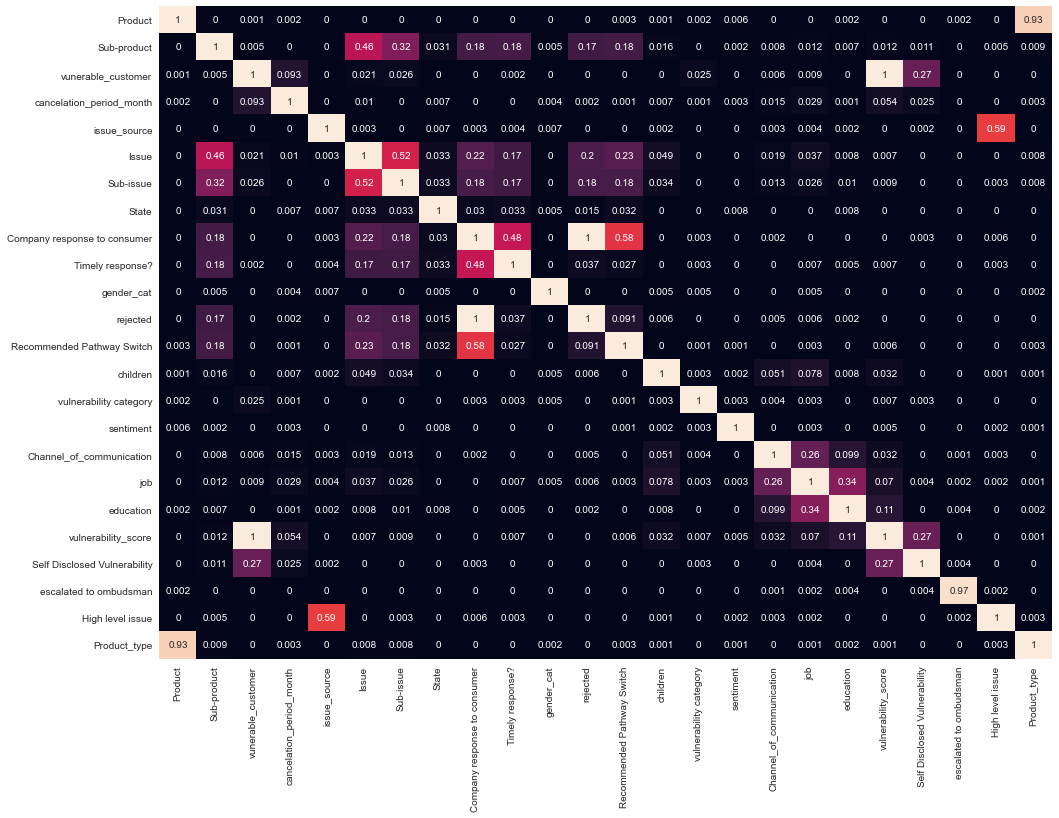

In [50]:
corr_cat = pd.DataFrame(data=data, index=cat_columns, columns=cat_columns)


plt.figure(figsize=(16, 12))
sns.heatmap(corr_cat, annot=True, cbar=False)
plt.show()

In [51]:
correlated_cols = set()
for name, row in corr_cat.iterrows():
    row = row.loc[:name][:-1]
    if len(row[row >= 0.5]) > 0:
        correlated_cols.add(name)
    
df.drop(correlated_cols, axis=1, inplace=True)
print(f"Colinear Features that has been dropped are...", correlated_cols)

Colinear Features that has been dropped are... {'Recommended Pathway Switch', 'Product_type', 'rejected', 'vulnerability_score', 'Sub-issue', 'High level issue'}


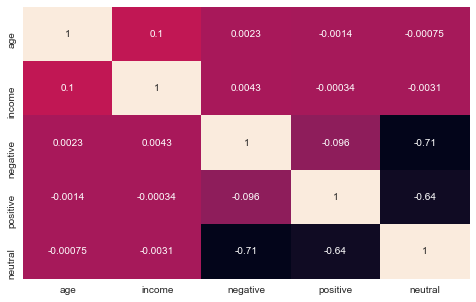

In [52]:
corr = df.select_dtypes(np.number).corr()

plt.figure(figsize=(8, 5))
sns.heatmap(corr, annot=True, cbar=False)
plt.show()

In [53]:
correlated_cols = set()
for name, row in corr.iterrows():
    row = row.loc[:name][:-1]
    if len(row[row >= 0.5]) > 0:
        correlated_cols.add(name)
    
    if len(row[row <= -0.5]) > 0:
        correlated_cols.add(name)
    
df.drop(correlated_cols, axis=1, inplace=True)
print(f"Colinear Features that has been dropped are...", correlated_cols)

Colinear Features that has been dropped are... {'neutral'}


In [54]:
df["children"] = df["children"].astype("int64")
df["Self Disclosed Vulnerability"] = df["Self Disclosed Vulnerability"].astype("int64")
df["escalated to ombudsman"] = df["escalated to ombudsman"].astype("int64")

In [55]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

for col in df.select_dtypes("O").drop(["Consumer complaint narrative", "vulnerability_level"], axis=1).columns:
    df[col] = encoder.fit_transform(df[col])

In [56]:
import re
import nltk
nltk.download("wordnet")
nltk.download("stopwords")

lemmatizer = nltk.stem.WordNetLemmatizer()
STOPWORDS = list(nltk.corpus.stopwords.words("english"))
STOPWORDS.append("XX")
STOPWORDS.append("XXXX")
STOPWORDS.append("xxxxxxxx")
STOPWORDS.append("xxxxxxxxxxxx")


# Function to clean the data
def clean_data(txt):
    txt = txt.lower()                             # lowering text
    txt = re.sub(r'\n', ' ', txt)                 # Removing Newline
    txt = re.sub(r"[^a-zA-Z]"," ", txt)        # Removing all special characters
    txt = " ".join([lemmatizer.lemmatize(i) for i in txt.split() if i not in STOPWORDS])   # Removing stopwrods and applying lemmatization
    return txt

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\autom\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\autom\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [57]:
df["Consumer complaint narrative"] = df["Consumer complaint narrative"].apply(clean_data)

In [58]:
X = df["Consumer complaint narrative"]
df.drop("Consumer complaint narrative", axis=1, inplace=True)

In [59]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(max_features=2000, min_df=2)

vec = vectorizer.fit_transform(X).toarray()

In [60]:
df_vec = pd.DataFrame(data=vec, columns=vectorizer.get_feature_names_out())

In [61]:
from sklearn.decomposition import PCA

svd = PCA(n_components=100)
X_reduced = svd.fit_transform(df_vec)

In [62]:
df_vec_reduced = pd.DataFrame(data=X_reduced, columns=svd.get_feature_names_out())

In [63]:
df_new = pd.concat([df, df_vec_reduced], axis=1)

In [64]:
X = df_new.drop("vulnerability_level", axis=1)
y = df_new.vulnerability_level

Total unique values are:  5 


Category	Value

Level 0 - not vulnerable            191870
Level 3 - moderate vulnerability      3188
Level 2 - mild vulnerability          2847
Level 4 - high vulnerability          1235
Level 1 - vulnerability prone          117
Name: vulnerability_level, dtype: int64


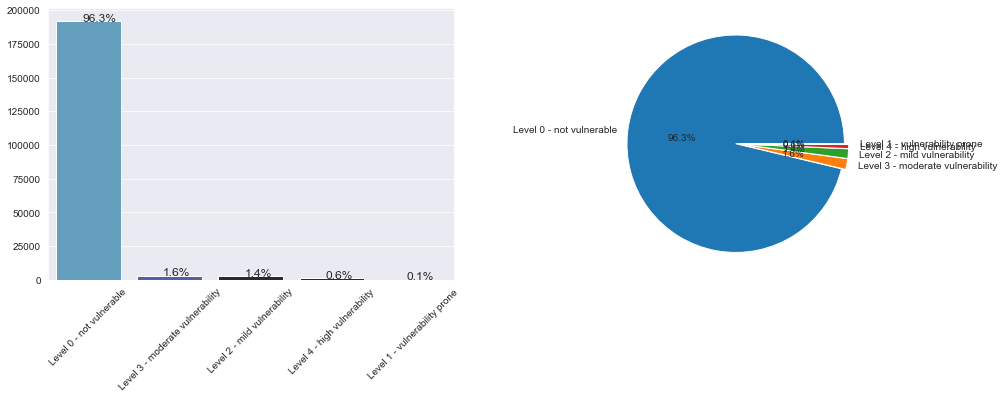

In [65]:
make_plots(y)

In [66]:
# Balancing data
from imblearn.over_sampling import SMOTE
sampler = SMOTE()
X, y = sampler.fit_resample(X, y)

Total unique values are:  5 


Category	Value

Level 0 - not vulnerable            191870
Level 2 - mild vulnerability        191870
Level 3 - moderate vulnerability    191870
Level 4 - high vulnerability        191870
Level 1 - vulnerability prone       191870
Name: vulnerability_level, dtype: int64


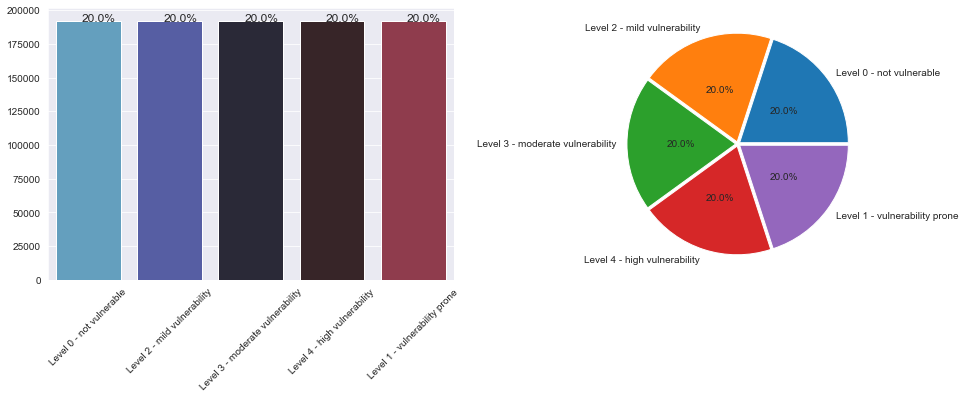

In [67]:
make_plots(y)